### Reading the data
This first block of code opens and reads the file using pandas library. It provided a datafram for a general picture on the structure of the data. df will be used as the main object holding all the data.

In [3]:
import pandas as pd

df = pd.read_csv('grades.csv')  # Replace with your file path
print(df.head())

#this reads the file into a dataframe within pandas

  FP130 FP130X HE111 HE111S HE111W HE111X HE112 HE112S HE112V HE112W  ...  \
0     V    NaN     V    NaN    NaN    NaN   NaN    NaN     A-    NaN  ...   
1     A    NaN     A    NaN    NaN    NaN     A    NaN    NaN    NaN  ...   
2   NaN      A     V    NaN    NaN    NaN   NaN    NaN    NaN    NaN  ...   
3    C+    NaN    A-    NaN    NaN    NaN     B    NaN    NaN    NaN  ...   
4     B    NaN    A-    NaN    NaN    NaN     A    NaN    NaN    NaN  ...   

  SM221X SM223 SM239 SP211 SP211P SP211R SP212 SP212P SP212R SY110  
0    NaN   NaN   NaN   NaN      A    NaN     A    NaN    NaN     A  
1    NaN   NaN   NaN   NaN    NaN    NaN   NaN    NaN    NaN     A  
2    NaN   NaN   NaN   NaN    NaN    NaN   NaN    NaN    NaN     A  
3    NaN     C   NaN     B    NaN    NaN    B+    NaN    NaN     C  
4    NaN   NaN   NaN     B    NaN    NaN     B    NaN    NaN    B-  

[5 rows x 40 columns]


### Finding the Median Grades
I first made a grading scale to convert the letter grade to numerical grades. Validated scores were left out and if a course was re-taken, I resulted to using the second grade recieved. This protocol was applied to all cells. Then the medians were computed over each class and then printed out with the course name and average next to it.

In [9]:
grade_to_numeric = {
    "A": 95, "A-": 91,
    "B+": 88, "B": 85, "B-": 81,
    "C+": 78, "C": 75, "C-": 71,
    "D+": 68, "D": 65, "D-": 61,
    "F": 55 
    # ignore validations or anything that is not a grade
}

#this function takes the last part of the grade which comes into play when there are re-takes
def convert_grade(value):
    if pd.isna(value):
        return None
    # Split on ";" and take the last part (assuming last is the actual grade)
    last_part = str(value).split(";")[-1].strip()
    return grade_to_numeric.get(last_part, None)

#apply the grade converter to all cells
df_numeric = df.map(convert_grade)

# Compute medians
medians = df_numeric.median()
#make a pretty data frame with all the calculated medians
medians_df = medians.to_frame("Median (100-pt scale)")

print(medians_df)

        Median (100-pt scale)
FP130                    88.0
FP130X                   85.0
HE111                    91.0
HE111S                   91.0
HE111W                   88.0
HE111X                   93.0
HE112                    91.0
HE112S                   95.0
HE112V                   95.0
HE112W                   88.0
HH104                    88.0
HH104X                   85.0
HH215                    91.0
HH215A                   88.0
HH215M                   88.0
HH216                    91.0
NE203                    91.0
NL110                    91.0
NN220                    88.0
NS101                    85.0
SC111                    81.0
SC112                    78.0
SC112R                   75.0
SM121A                   78.0
SM122                    81.0
SM122R                   83.0
SM122X                   85.0
SM131                    65.0
SM221                    85.0
SM221P                   91.0
SM221X                   85.0
SM223                    85.0
SM239     

### Most D's and F's
Similar to before, the second grade (if retaken) was counted. All variations of D's and F's were calculated for each class. The list with total values of these classes were then ranked and the top three were taken and included in the graph. The percent low was added for comparison and the number was rounded to be more visually appealing.

In [21]:
# --- Extract final grade (handles retakes) ---
def extract_final_grade(value):
    if pd.isna(value):
        return None
    last_part = str(value).split(";")[-1].strip()
    return last_part if last_part in grade_to_numeric else None

# --- Step 1: Clean grades to final letter ---
df_clean = df.map(extract_final_grade)

# --- Step 2: Count D's and F's per class ---
risk_summary = []

for col in df_clean.columns:
    grades = df_clean[col].dropna()
    
    low_count = grades.isin(["D+", "D", "D-", "F"]).sum()
    total_students = len(grades)

    percent_low = (low_count / total_students * 100) if total_students > 0 else 0
    percent_low = round(percent_low)   # just a number, no decimals    
    
    risk_summary.append({
        "Class": col,
        "Low_Grades (D/F)": low_count,
        "Total Students": total_students,
        "Percent Low": percent_low
    })

# --- Step 3: Build DataFrame and rank ---
risk_df = pd.DataFrame(risk_summary)
risk_df = risk_df.sort_values("Low_Grades (D/F)", ascending=False).reset_index(drop=True)
risk_df.insert(0, "Rank", risk_df.index + 1)

# --- Step 4: Show top 3 classes (no index column in Jupyter) ---
display(risk_df.head(3).style.hide(axis="index"))

Rank,Class,Low_Grades (D/F),Total Students,Percent Low
1,SC112,808,5185,16
2,SC111,660,5318,12
3,SM122,599,4715,13


### Most A's
Similar to before, the second grade (if retaken) was counted. All variations of A's were calculated for each class. The list with total values of these classes were then ranked and the top three were taken and included in the graph. The percent high was added for comparison and the number was rounded to be more visually appealing. This process was identical from the section above, except we looked for different grades.

In [25]:
# Step 1: Clean grades (use last entry if multiple)
df_clean = df.map(extract_final_grade)

# Step 2: Valid grades (we only want those in mapping)
valid_grades = list(grade_to_numeric.keys())
df_clean = df_clean.map(lambda g: g if g in valid_grades else None)

# Step 3: Count A’s per class
risk_summary = []

for col in df_clean.columns:
    grades = df_clean[col].dropna()
    
    # Count only low grades
    high_count = grades.isin(["A+", "A", "A-"]).sum()
    
    # Total students (valid grades only)
    total_students = len(grades)

    percent_high = (high_count / total_students * 100) if total_students > 0 else 0
    percent_high = round(percent_high)   # round to ones place   
    # Build row
    risk_summary.append({
        "Class": col,
        "High_Grades (A's!)": high_count,
        "Total Students": total_students,
        "Percent High": percent_high
    })

# Step 4: Make DataFrame and rank
risk_df = pd.DataFrame(risk_summary)
risk_df = risk_df.sort_values("High_Grades (A's!)", ascending=False).reset_index(drop=True)

risk_df.insert(0, "Rank", risk_df.index + 1)

display(risk_df.head(3).style.hide(axis="index"))

Rank,Class,High_Grades (A's!),Total Students,Percent High
1,NL110,3680,5753,64
2,NE203,2868,4501,64
3,HH104,2643,5665,47


### Histograms
Three histrograms are created for Calc II, physics, and english. Validated classes were included on the graphs. The x-axis is the alphabetical grades recieved
and the y-axis is the number of students. The clean data from above was used and each grade was counted and then applied to each 
class.

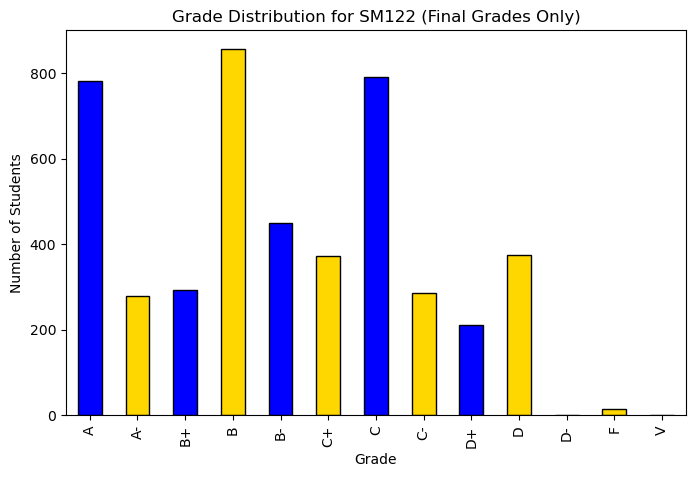

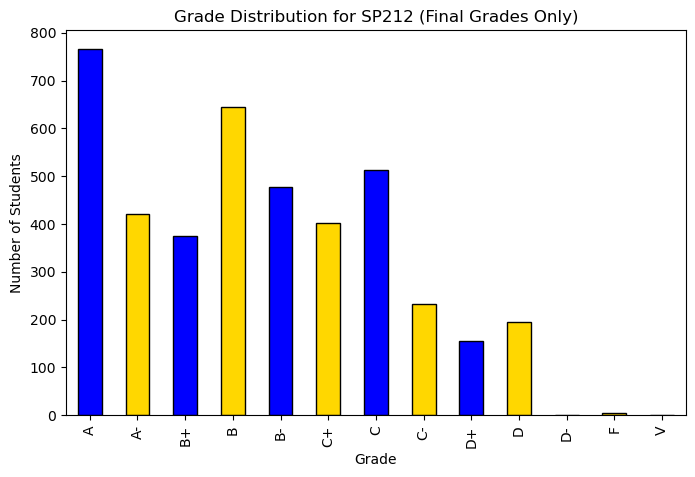

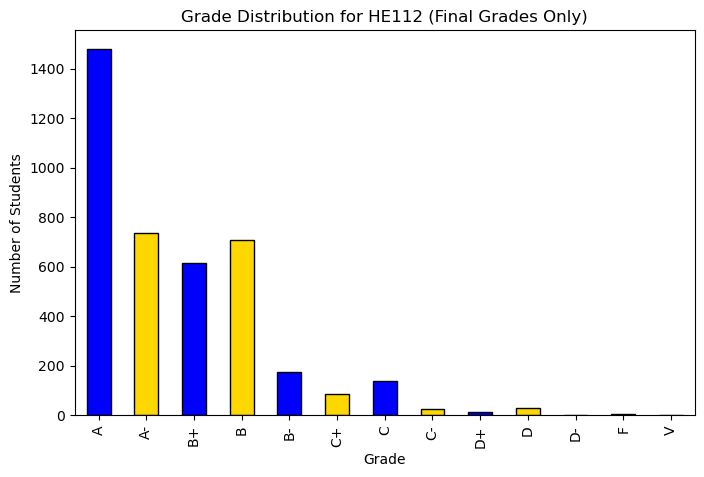

In [26]:
import matplotlib.pyplot as plt

valid_grades_with_v = list(grade_to_numeric.keys()) + ["V"]

# Build alternating colors list
colors = ["blue", "gold"] * (len(valid_grades_with_v) // 2 + 1)
colors = colors[:len(valid_grades_with_v)]  # trim to right length

def plot_class_histogram(df_clean, class_code):
    """Plot grade distribution for a given class with alternating blue/gold bars."""
    grades = df_clean[class_code].dropna()
    grades = grades[grades.isin(valid_grades_with_v)]
    
    counts = grades.value_counts().reindex(valid_grades_with_v, fill_value=0)
    
    plt.figure(figsize=(8, 5))
    counts.plot(
        kind="bar",
        color=colors,
        edgecolor="black"
    )
    plt.title(f"Grade Distribution for {class_code} (Final Grades Only)")
    plt.xlabel("Grade")
    plt.ylabel("Number of Students")
    plt.show()

# Plot for your three classes
plot_class_histogram(df_clean, "SM122")
plot_class_histogram(df_clean, "SP212")
plot_class_histogram(df_clean, "HE112")

#due to wanting to include validated grades, I chose to make the x-axis the letter grades versus a range

### Pearson Correlation Between Into To Seamanship and Rest of Courses
The pearson coefficient was calculated between NS101 and every other course. The coefficient came from the overall performance in the class and compared to overall performance in the other. The higher the coeficient means the closer the performance between the two classes was. To elaborate, a value closer to one means a student in NS101 also performed well in another class. I was suprised by the lower value due to the fact that USNA usually has similar trends for students. However, this could be due to other resources or classes being taken in different semesters. A high number for SC112 means that students who do well in NS101 also, relatively, perfrom well in SC112. There were no classes negatively correlated with NS101 which makes sense since grades are somewhat of a consisent data point.

In [30]:
# --- Step 1: Convert letter grades to numeric ---
df_numeric = df_clean.map(lambda g: grade_to_numeric.get(g, None))

# --- Step 2: Pick the course you want to compare ---
target_course = "NS101"

if target_course in df_numeric.columns:
    correlations = {}

    for course in df_numeric.columns:
        if course == target_course:
            continue
        # Only compute correlation if there are >=2 overlapping grades
        valid_idx = df_numeric[[target_course, course]].dropna().index
        if len(valid_idx) >= 2:
            correlations[course] = df_numeric.loc[valid_idx, target_course].corr(df_numeric.loc[valid_idx, course])
        else:
            correlations[course] = None  # mark insufficient data

    # Build DataFrame
    correlation_df = pd.DataFrame({
        "Course": correlations.keys(),
        f"Correlation with {target_course}": [
            val if val is not None else "Insufficient data" for val in correlations.values()
        ]
    })

    # Sort numeric correlations descending, leave "Insufficient data" at bottom
    numeric_df = correlation_df[correlation_df[f"Correlation with {target_course}"] != "Insufficient data"]
    non_numeric_df = correlation_df[correlation_df[f"Correlation with {target_course}"] == "Insufficient data"]
    correlation_df = pd.concat([numeric_df.sort_values(f"Correlation with {target_course}", ascending=False),
                                non_numeric_df], ignore_index=True)

    display(correlation_df.style.hide(axis="index"))

else:
    print(f"{target_course} does not have enough valid grades for correlation.")

Course,Correlation with NS101
SC112,0.650342
SC111,0.639902
SP211P,0.631464
SY110,0.622649
SP212,0.599474
SM239,0.582439
SM221,0.582245
SP211,0.580330
NN220,0.579050
SM122R,0.573433


### Class Validated and Average Grade
The goal of this was to see if there was a connection between the number of people who validated a course and the average grade in the course. The courses with 0 validations were grouped into one data point as the average of their overall grade. As shown by the graph, there is no compelling correlation between the two variables.

        Validations  Average Performance
FP130           864            82.348406
HE111           976            86.741435
HH104            11            82.333392
HH215             3            89.587148
HH215A            1            82.103825


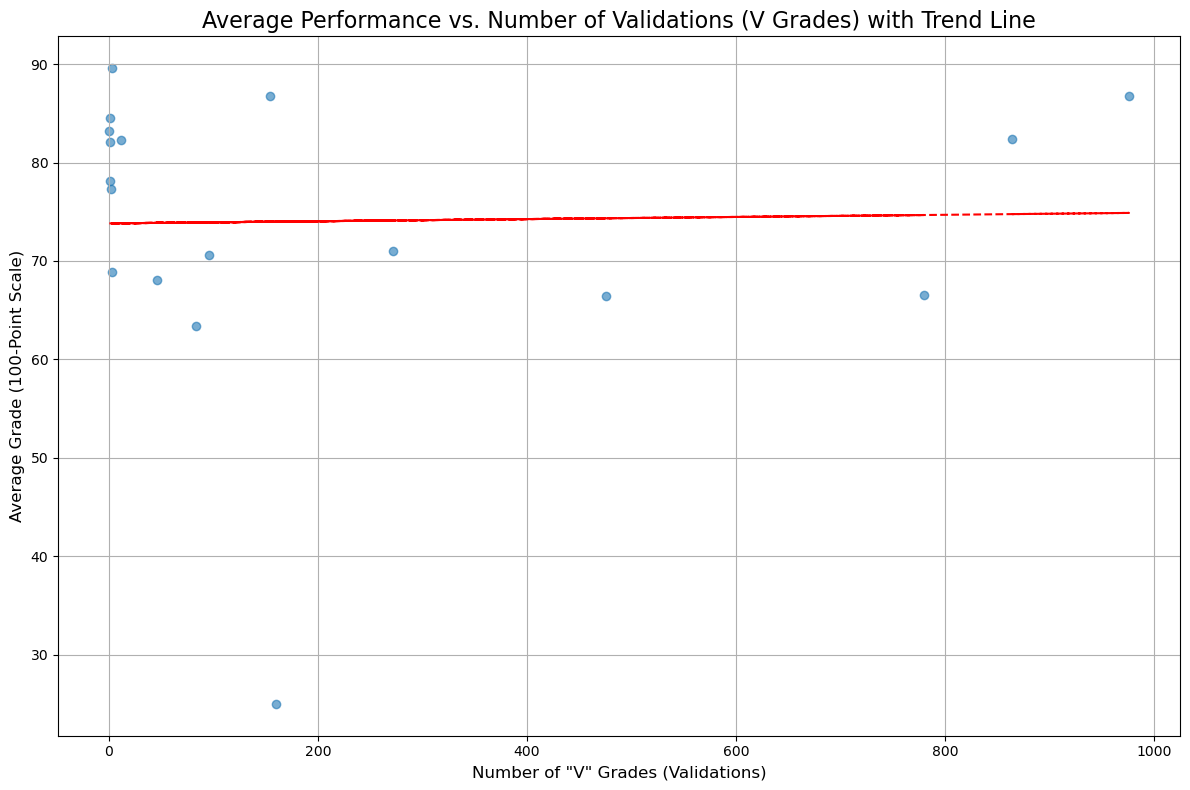

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("grades.csv")

# Define the grade to numerical value mapping on a 4.0 scale
grade_map_4_0 = {
    'A': 4.0, 'A-': 3.7, 'A+': 4.0,
    'B+': 3.3, 'B': 3.0, 'B-': 2.7,
    'C+': 2.3, 'C': 2.0, 'C-': 1.7,
    'D+': 1.3, 'D': 1.0, 'D-': 0.7
    # 'RF' and other grades not in this map will be treated as NaN
}

# Define the function to extract the final grade
def extract_final_grade(value):
    if pd.isna(value):
        return None
    last_part = str(value).split(";")[-1].strip()
    return last_part if last_part in grade_map_4_0 else None

# Calculate the number of "validations" (V grades) for each class
validations = (df == 'V').sum()

# Apply the function to the entire DataFrame to handle semicolon grades for average grade calculation
df_processed = df.map(extract_final_grade)

# Identify base and retake columns based on 'R' suffix
retake_columns = [col for col in df_processed.columns if col.endswith('R')]
base_columns = [col.replace('R', '') for col in retake_columns]

# Create a new DataFrame for consolidated grades
df_consolidated = df_processed.copy()

# Consolidate grades, prioritizing the 'R' (retake) grade
for base, retake in zip(base_columns, retake_columns):
    if base in df_consolidated.columns and retake in df_consolidated.columns:
        df_consolidated[base] = df_consolidated[retake].fillna(df_consolidated[base])
        df_consolidated.drop(columns=[retake], inplace=True)

# Create a new DataFrame to store numerical grades
df_numerical = pd.DataFrame()

# Convert grades to numerical values for all columns in the consolidated DataFrame
for col in df_consolidated.columns:
    df_numerical[col] = df_consolidated[col].apply(lambda x: grade_map_4_0.get(x, np.nan))

# Convert the 4.0 scale to a 100-point scale
df_numerical_100 = (df_numerical / 4.0) * 100

# Calculate the average performance for each class
average_performance = df_numerical_100.mean()

# Combine the two Series into a new DataFrame
analysis_df = pd.DataFrame({
    'Validations': validations,
    'Average Performance': average_performance
})

# Drop any rows with NaN values (classes with no grades)
analysis_df.dropna(inplace=True)

# Group classes with 0 validations and average their performance
zero_validations_df = analysis_df[analysis_df['Validations'] == 0]
other_validations_df = analysis_df[analysis_df['Validations'] > 0]

if not zero_validations_df.empty:
    # Calculate the average performance of all classes with 0 validations
    avg_performance_zero_validations = zero_validations_df['Average Performance'].mean()
    # Create a single data point for this group
    zero_validations_point = pd.DataFrame({
        'Validations': [0],
        'Average Performance': [avg_performance_zero_validations]
    })
    # Concatenate the new single data point with the rest of the data
    analysis_df = pd.DataFrame(pd.concat([other_validations_df, zero_validations_point]))
else:
    # If there are no classes with 0 validations, just use the original dataframe
    analysis_df = other_validations_df

# Set up the plot
plt.figure(figsize=(12, 8))
plt.scatter(analysis_df['Validations'], analysis_df['Average Performance'], alpha=0.6)

# Calculate and plot the trend line using numpy's polyfit
z = np.polyfit(analysis_df['Validations'], analysis_df['Average Performance'], 1)
p = np.poly1d(z)
plt.plot(analysis_df['Validations'], p(analysis_df['Validations']), "r--")

# Add title and labels for clarity
plt.title('Average Performance vs. Number of Validations (V Grades) with Trend Line', fontsize=16)
plt.xlabel('Number of "V" Grades (Validations)', fontsize=12)
plt.ylabel('Average Grade (100-Point Scale)', fontsize=12)
plt.grid(True)
plt.tight_layout()

# Save the plot to a file
plt.savefig('validations_vs_performance.png')

# Print the final DataFrame head to confirm the data
print(analysis_df.head())
